To run nebula scirbt you need the follwing libraries:

```R
    library(glue)
    library(dplyr)
    library(getopt)
    library(Matrix)
    library(qs)
    library(Seurat)
    library(nebula)
    library(future)
```

```R
install.packages("getopt")

if (!require("devtools")) install.packages("devtools")
devtools::install_github("lhe17/nebula")

if (!require("BiocManager")) install.packages("BiocManager")
BiocManager::install("biomaRt")

```

R scritp from [link](https://github.com/bdferris642/sc-online/tree/main/scripts)

# Hyperparameters

In [ ]:
%load_ext autoreload
%autoreload 2



import pandas as pd
import numpy as np
from scipy import sparse
import scanpy as sc
import matplotlib.pyplot as plt
import os
import rpy2.robjects as ro

from dotenv import load_dotenv; load_dotenv()


from utils import preprocessing
from utils import DEG

# ATTENTION: need for perpty of running jupternotbook
%matplotlib inline

GRADIENT_GENES_CORR_PATH = os.getenv("GRADIENT_GENES_CORR_PATH")
PARALLEL_NEBULA_SCRIPT_PATH = os.getenv("PARALLEL_NEBULA_SCRIPT")


ADATA_PATH = f"/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/zonated_objs_combined_with_md__combined__rep_001__ventral_matrix_keep_1.0_raw.h5ad"
adata_path_name=f"{os.path.split(ADATA_PATH)[1].split('.')[0]}"
ADATA_PATH_BASE = os.path.splitext(ADATA_PATH)[0]
ADATA_FOLDER = os.path.dirname(ADATA_PATH)
SAVE_FOLDER = f"/home/gdallagl/myworkdir/XDP/data/artificial_DEG_analysis/baseline/{adata_path_name}"
QS_TMP_FOLDER = "/home/gdallagl/myworkdir/XDP/data/_old/nebula_tmp" # tmp folder where to save intemrediate results
TRUE_DEG_PATH = f"{ADATA_FOLDER}/genes.csv"
os.makedirs(SAVE_FOLDER, exist_ok=True)

# name of cell tyoe vauble annotaton to use in this analsys
CT_FOR_DEG_VARIABLE = "spn_type" #"Group_name",  "spn_type"
# name of Sample varibale
SAMPLE_VARIABLE = "donor_id"
# variable to test if differtially epxressed
CONTRAST_VARIABLE = "case_control"
# Level of contrat varibale to use as baseline
CONTRAST_BASELINE = "control"
# Level of contrat varibale to use as stimulated
CONTRAST_STIM = "case"

# Covariates to use for stat test
COVARIATES_FOR_DEG = ["Age.at.Death", "Sex", "PMI", "pct_mt", "pct_intronic",
                      ]
# libraru size col for  enbula
LIBRARY_SIZE_COL = "nCount_RNA"

# mitluple etst correction pvalue thr
ALPHA_MULTIPLE_TEST = 0.05
LOGFC_THR=0.1
PVAL_THR=0.05

# Read adata

In [ ]:
adata = sc.read_h5ad(
    #"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/original_data/NucSeq_all_labelled_zoned.h5ad", 
    ADATA_PATH,
    backed="r"
    )

#adata = adata[adata.obs.spn_type == "dorsal_matrix"][:50000].copy()


adata

AnnData object with n_obs × n_vars = 191639 × 37905 backed at '/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/zonated_objs_combined_with_md__combined__rep_001__ventral_matrix_keep_1.0_raw.h5ad'
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'donor_id', 'PREFIX', 'CELL_BARCODE', 'NUM_GENIC_READS', 'NUM_TRANSCRIPTS', 'NUM_GENES', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_genic', 'pct_intronic', 'pct_mt', 'pct_ribosomal', 'frac_contamination', 'experiment', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Class_name', 'Class_bootstrapping_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Group_name', 'Group_bootstrapping_probability', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'x', 'y', 'library', 'donor', 'x_um2', 'y_um2', 'unique_cell_ID', 'cb', 'Final_Zone_Assignments', 'Group_name.1', 'cell_type', 'Cohort', 'Biobank', 'Age.at.Death', 'Sex', 'Race', 'Ethnicity', 'Ca

# Make qs files

Specific for cell type (all samples together).

In [ ]:
# Initialize X_umap if it doesn't exist
if 'X_umap' not in adata.obsm:
    adata.obsm['X_umap'] = np.full((adata.shape[0], 2), np.nan)

for ct in adata.obs[CT_FOR_DEG_VARIABLE].unique():

    a = adata[adata.obs[CT_FOR_DEG_VARIABLE] == ct].copy()

    print(ct,"\n", a)

    #############################
    # Save counts

    if "counts" in a.layers:
        print("Putting raw counts in .X")
        a.X = a.layers["counts"].copy()
    else:
        a.layers["counts"] = a.X.copy()
        print("Be sure that .X is raw counts")    

    #############################
    # Save qs

    print("\tSaving files for R coversion...")
    preprocessing.save_files_for_R_conversion(a, QS_TMP_FOLDER)
    print("\tBuilding R obj...")
    saving_path = os.path.join(SAVE_FOLDER, f"{ct.replace(' ', '_')}.qs")
    preprocessing.build_qs_from_python_files(QS_TMP_FOLDER, saving_path=saving_path, contrast_var=CONTRAST_VARIABLE, reference_level=CONTRAST_BASELINE)

    #break

ventral_matrix 
 AnnData object with n_obs × n_vars = 48688 × 37905
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'donor_id', 'PREFIX', 'CELL_BARCODE', 'NUM_GENIC_READS', 'NUM_TRANSCRIPTS', 'NUM_GENES', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_genic', 'pct_intronic', 'pct_mt', 'pct_ribosomal', 'frac_contamination', 'experiment', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Class_name', 'Class_bootstrapping_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Group_name', 'Group_bootstrapping_probability', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'x', 'y', 'library', 'donor', 'x_um2', 'y_um2', 'unique_cell_ID', 'cb', 'Final_Zone_Assignments', 'Group_name.1', 'cell_type', 'Cohort', 'Biobank', 'Age.at.Death', 'Sex', 'Race', 'Ethnicity', 'Cause.of.Death', 'PMI', 'spn_type', 'case_control', 'RNA_snn_res.0.2', 'seurat_clusters', 'RNA_snn_res.0.5', 'Row.names', 'PC_1', 'PC_2', 'PC_3', 'P

2026-01-29 19:42:34 | [WARNING] R callback write-console: Loading required package: SeuratObject
  
2026-01-29 19:42:34 | [WARNING] R callback write-console: Loading required package: sp
  
2026-01-29 19:42:35 | [WARNING] R callback write-console: 
Attaching package: ‘SeuratObject’

  
2026-01-29 19:42:35 | [WARNING] R callback write-console: The following objects are masked from ‘package:base’:

    %||%, intersect, t

  



    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

2026-01-29 19:42:38 | [WARNING] R callback write-console: 
Attaching package: ‘Seurat’

  
2026-01-29 19:42:38 | [WARNING] R callback write-console: The following object is masked from ‘package:base’:

    %||%

  
2026-01-29 19:42:38 | [WARNING] R callback write-console: qs 0.27.3. Announcement: https://github.com/qsbase/qs/issues/103
  



Setting case_control reference level to: control
Levels: control case 


...

2026-01-29 19:52:39 | [WARNING] R callback write-console: Warning:  
2026-01-29 19:52:39 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


espn 
 AnnData object with n_obs × n_vars = 31973 × 37905
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'donor_id', 'PREFIX', 'CELL_BARCODE', 'NUM_GENIC_READS', 'NUM_TRANSCRIPTS', 'NUM_GENES', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_genic', 'pct_intronic', 'pct_mt', 'pct_ribosomal', 'frac_contamination', 'experiment', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Class_name', 'Class_bootstrapping_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Group_name', 'Group_bootstrapping_probability', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'x', 'y', 'library', 'donor', 'x_um2', 'y_um2', 'unique_cell_ID', 'cb', 'Final_Zone_Assignments', 'Group_name.1', 'cell_type', 'Cohort', 'Biobank', 'Age.at.Death', 'Sex', 'Race', 'Ethnicity', 'Cause.of.Death', 'PMI', 'spn_type', 'case_control', 'RNA_snn_res.0.2', 'seurat_clusters', 'RNA_snn_res.0.5', 'Row.names', 'PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_

2026-01-29 19:56:32 | [WARNING] R callback write-console: Warning:  
2026-01-29 19:56:32 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


patch 
 AnnData object with n_obs × n_vars = 38033 × 37905
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'donor_id', 'PREFIX', 'CELL_BARCODE', 'NUM_GENIC_READS', 'NUM_TRANSCRIPTS', 'NUM_GENES', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_genic', 'pct_intronic', 'pct_mt', 'pct_ribosomal', 'frac_contamination', 'experiment', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Class_name', 'Class_bootstrapping_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Group_name', 'Group_bootstrapping_probability', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'x', 'y', 'library', 'donor', 'x_um2', 'y_um2', 'unique_cell_ID', 'cb', 'Final_Zone_Assignments', 'Group_name.1', 'cell_type', 'Cohort', 'Biobank', 'Age.at.Death', 'Sex', 'Race', 'Ethnicity', 'Cause.of.Death', 'PMI', 'spn_type', 'case_control', 'RNA_snn_res.0.2', 'seurat_clusters', 'RNA_snn_res.0.5', 'Row.names', 'PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC

2026-01-29 20:00:13 | [WARNING] R callback write-console: Warning:  
2026-01-29 20:00:13 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


# DEG

In [ ]:
for ct in adata.obs[CT_FOR_DEG_VARIABLE].unique():

    print(ct,"\n")

    # Run Nebula
    nebula_result_path = DEG.run_nebula_parallel_script(
        path_qs = os.path.join(SAVE_FOLDER, f"{ct.replace(' ', '_')}.qs"),
        path_nebula_script = PARALLEL_NEBULA_SCRIPT_PATH,
        id_col = SAMPLE_VARIABLE,
        covs = [CONTRAST_VARIABLE, *COVARIATES_FOR_DEG], # wihtout LIBRARY_SIZE_COL, with constrst vaibale too
        offset_col = LIBRARY_SIZE_COL,
        n_folds = 8,
        n_cores = 16,
        save_tmp = False,
        suffix = None,
    )

    # save csv
    csv_path = os.path.join(SAVE_FOLDER, f"{ct.replace(' ', '_')}_nebula_results.csv")
    ro.r(f'''
        library(qs)
        obj <- qread("{nebula_result_path}")
        df <- obj$summary
        write.csv(df, "{csv_path}", row.names = FALSE)
    ''')

    #break
    

patch 

Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/artificial_DEG_analysis/dorsal-ventral-score/zonated_objs_combined_with_md__combined__rep_001__ventral_matrix_keep_1/patch.qs --id-col donor_id --offset-col nCount_RNA --n-folds 8 --n-cores 16 --save-tmp 0 --covs case_control,Age.at.Death,Sex,PMI,pct_mt,pct_intronic,gradient_score


# Plot Results

In [4]:
df_true_degs = pd.read_csv(TRUE_DEG_PATH)
df_true_degs


,gene_id,log2fc,frac_applied,n_subjects_applied,subjects_applied
0,ENSG00000237280,0.522222,0.3,3,"MD9129,MS986638,UMBEB23076"
1,ENSG00000250027,0.733333,0.7,7,"MD9129,MS30499,MS706984,MS876075,MS986638,UMBE..."
2,ENSG00000289321,-0.733333,0.4,4,"MD6927,MS30499,MS876075,MS986638"
3,OTULIN,0.100000,0.6,6,"MD6927,MD9129,MS30499,MS876075,MS986638,UMBEB2..."
4,MYLIP,-0.522222,0.2,2,"MD6927,UMBEB22074"
...,...,...,...,...,...
395,FLVCR2,0.733333,0.1,1,UMBEB23158
396,PTPN20,1.577778,0.5,5,"MD6927,MS30499,MS706984,UMBEB22074,UMBEB23158"
397,RACGAP1,-0.100000,0.7,7,"MD6927,MD9129,MS30499,UMBEB22074,UMBEB23076,UM..."
398,ENSG00000257239,2.000000,0.5,5,"MS706984,MS876075,MS986638,UMBEB23076,UMBEB24013"



#################
dorsal_matrix
#################



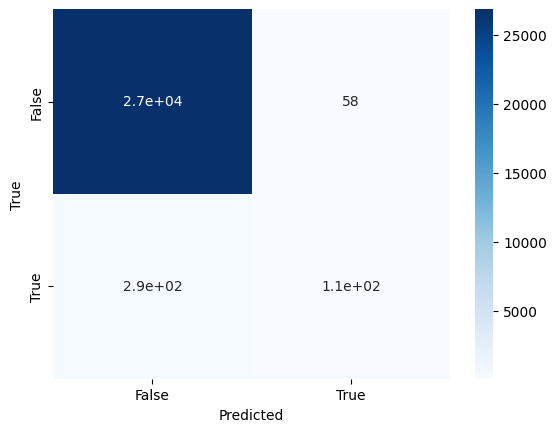

Precision: 0.646
Recall:    0.265
F1 Score:  0.376
Accuracy:  0.987
Clipping 15 genes with -log10(p) > 10


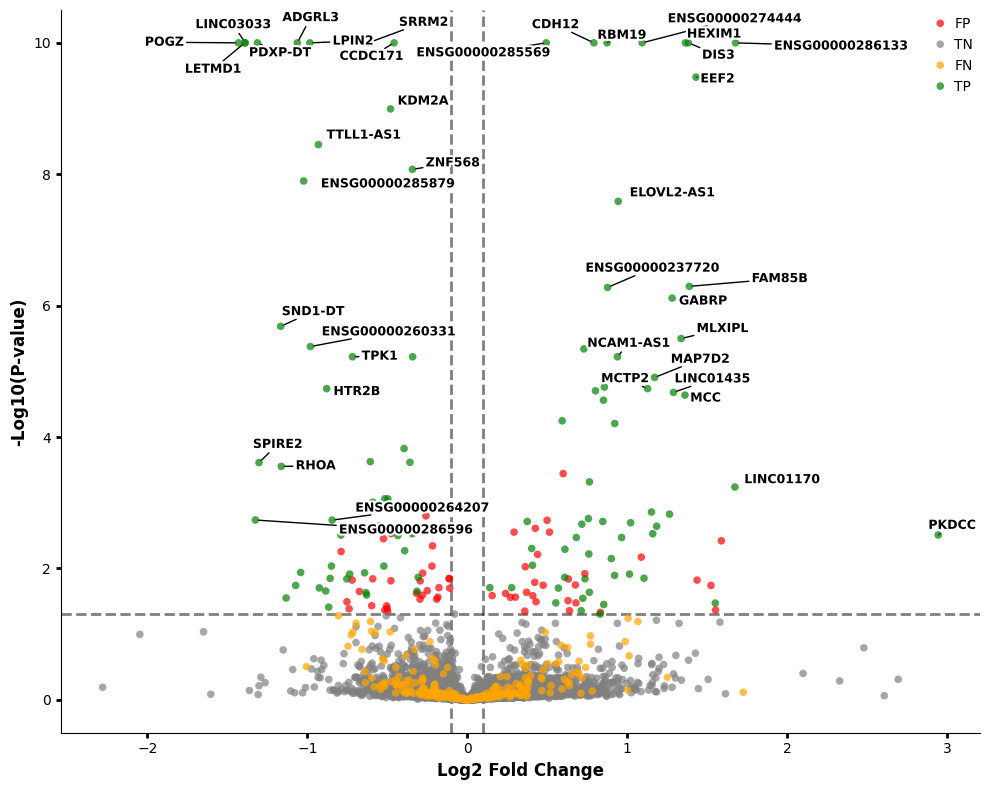

,gene,logFC_case_controlcase,p_case_controlcase,adj_p_case_controlcase,is_significant,is_true_DEG,-log10p,category,sorter
0,A1BG,-0.183638,0.000138,0.027306,True,False,1.563743,FP,-0.287163
1,A1BG-AS1,-0.041500,0.464718,0.896652,False,False,0.047376,TN,-0.001966
2,A1CF,-0.326385,0.002652,0.241381,False,False,0.617298,TN,-0.201477
3,A2M,0.231409,0.198097,0.827785,False,False,0.082083,TN,0.018995
4,A2M-AS1,0.045054,0.473462,0.897976,False,False,0.046735,TN,0.002106
...,...,...,...,...,...,...,...,...,...
27314,ZZEF1,-0.048073,0.084349,0.752632,False,False,0.123417,TN,-0.005933
27315,ZZZ3,0.006815,0.916880,0.987007,False,False,0.005680,TN,0.000039
27316,ENSG00000205653,0.516017,0.422843,0.885219,False,False,0.052949,TN,0.027323
27317,ENSG00000223438,-0.110867,0.866066,0.977244,False,False,0.009997,TN,-0.001108


In [ ]:
for ct in adata.obs[CT_FOR_DEG_VARIABLE].unique():

    print(f"\n#################\n{ct}\n#################\n")

    csv_path = os.path.join(SAVE_FOLDER, f"{ct.replace(' ', '_')}_nebula_results.csv")

    df_nebula = pd.read_csv(csv_path)

    DEG.plot_nebula_results(df_nebula, 
                        df_true_degs, 
                        col_p=f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                        col_logFC=f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                        col_gene="gene",
                        PVAL_THR=PVAL_THR,
                        LOGFC_THR=LOGFC_THR,
                        max_FDR=10,
                        add_adj_p_col=True
                        )
    break

# Over All Plot

ventral_matrix


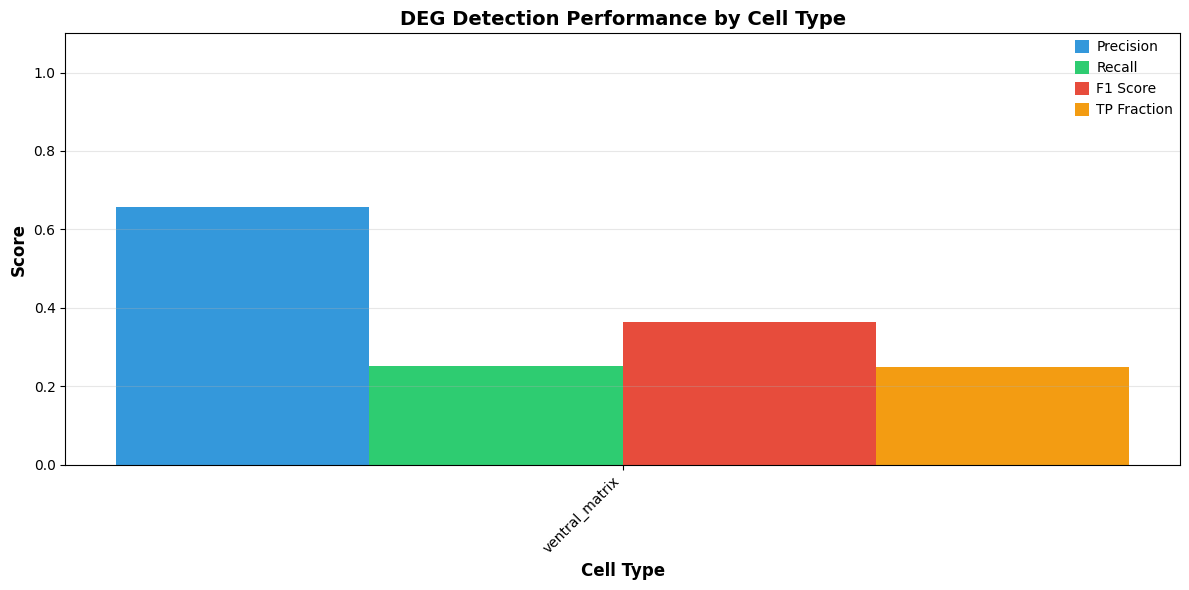


Metrics Summary:
     Cell Type  Precision   Recall       F1  TP Fraction
ventral_matrix   0.657895 0.250627 0.362976         0.25


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Collect metrics for all cell types
results = []

for ct in adata.obs[CT_FOR_DEG_VARIABLE].unique():

    print(ct)
    
    # Read CSV
    csv_path = os.path.join(SAVE_FOLDER, f"{ct.replace(' ', '_')}_nebula_results.csv")
    df_nebula = pd.read_csv(csv_path)
        
    # Calculate adjusted p-values
    from statsmodels.stats.multitest import multipletests
    col_p_adj = f"adj_p_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
    df_nebula[col_p_adj] = multipletests(df_nebula[f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}"], method="fdr_bh")[1]
    
    # Determine significance
    df_nebula["is_significant"] = (
        (df_nebula[col_p_adj] <= PVAL_THR) & 
        (np.abs(df_nebula[f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}"]) >= LOGFC_THR)
    )
    df_nebula["is_true_DEG"] = df_nebula["gene"].isin(df_true_degs["gene_id"])
    
    # Calculate metrics
    precision = precision_score(df_nebula["is_true_DEG"], df_nebula["is_significant"])
    recall = recall_score(df_nebula["is_true_DEG"], df_nebula["is_significant"])
    f1 = f1_score(df_nebula["is_true_DEG"], df_nebula["is_significant"])
    
    # TP fraction
    tp = (df_nebula["is_true_DEG"] & df_nebula["is_significant"]).sum()
    tp_fraction = tp / df_true_degs.shape[0]
    
    results.append({
        'Cell Type': ct,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'TP Fraction': tp_fraction
    })

    break

# Create dataframe
df_metrics = pd.DataFrame(results)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_metrics))
width = 0.2

ax.bar(x - 1.5*width, df_metrics['Precision'], width, label='Precision', color='#3498db')
ax.bar(x - 0.5*width, df_metrics['Recall'], width, label='Recall', color='#2ecc71')
ax.bar(x + 0.5*width, df_metrics['F1'], width, label='F1 Score', color='#e74c3c')
ax.bar(x + 1.5*width, df_metrics['TP Fraction'], width, label='TP Fraction', color='#f39c12')

ax.set_xlabel('Cell Type', fontweight='bold', fontsize=12)
ax.set_ylabel('Score', fontweight='bold', fontsize=12)
ax.set_title('DEG Detection Performance by Cell Type', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(df_metrics['Cell Type'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Display table
print("\nMetrics Summary:")
print(df_metrics.to_string(index=False))



---
---
---

In [ ]:
# for ct in adata.obs[CT_FOR_DEG_VARIABLE].unique():

#     path_qs = f"{QS_TMP_FOLDER}/{ct.replace(' ', '_')}.qs"
#     output_csv = f"{QS_TMP_FOLDER}/{ct.replace(' ', '_')}_nebula_results.csv"

#     print(ct, "\n", path_qs, "\n", output_csv)
    
#     import rpy2.robjects as ro

#     ro.r(f"""
#         library(nebula)
#         library(qs)
#         library(Seurat)
        
#         # Load Seurat object
#         cat("Loading", "{ct}", "...\\n")
#         sobj <- qread("{path_qs}")
        
#         # Extract count matrix (genes x cells) - Seurat v5
#         count_matrix <- GetAssayData(sobj, assay = "RNA", layer = "counts")
#         #count_matrix <- as.matrix(count_matrix)

#         # ========== CRITICAL: FILTER GENES FIRST ==========
#         # Remove genes with very low expression
#         genes_total_counts <- Matrix::rowSums(count_matrix)
#         genes_n_cells <- Matrix::rowSums(count_matrix > 0)
        
#         # Keep only genes with:
#             # - At least 50 cells expressing
#             # - At least 100 total counts across all cells
#         keep_genes <- (genes_n_cells >= 50) & (genes_total_counts >= 100)
#         cat("Genes before filtering:", nrow(count_matrix), "\\n")
#         count_matrix <- count_matrix[keep_genes, ]
#         cat("Genes after filtering:", nrow(count_matrix), "\\n")
        
        
#         # Extract metadata
#         meta <- sobj@meta.data
        
#         # CRITICAL: Ensure factors are properly coded
#         # Convert condition to factor if it isn't already
#         meta${CONTRAST_VARIABLE} <- as.factor(meta${CONTRAST_VARIABLE})
        
#         # Get ID vector (must be factor for NEBULA)
#         id <- as.factor(meta[["{SAMPLE_VARIABLE}"]])
        
#         # Get offset (library size)
#         offset <- meta[["{LIBRARY_SIZE_COL}"]]
        
#         cat("\\nData dimensions:\\n")
#         cat("  Genes:", nrow(count_matrix), "\\n")
#         cat("  Cells:", ncol(count_matrix), "\\n")
#         cat("  Subjects:", length(unique(id)), "\\n")
#         cat("  Condition levels:", levels(meta${CONTRAST_VARIABLE}), "\\n")
        
#         # Build DESIGN MATRIX (not just data frame!)
#         # NEBULA needs model.matrix format with intercept
#         pred_formula <- as.formula("~ {' + '.join([CONTRAST_VARIABLE, *COVARIATES_FOR_DEG])}")
#         pred_matrix <- model.matrix(pred_formula, data = meta)
        
#         cat("\\nPredictor matrix dimensions:", dim(pred_matrix), "\\n")
#         cat("Predictor columns:", colnames(pred_matrix), "\\n")
        
#         # Group cells by subject (recommended for speed and accuracy)
#         # Try to group (reorder) cells by subject
#         data_g <- group_cell(
#             count = count_matrix,
#             id = id,
#             pred = pred_matrix,
#             offset = offset
#         )
        
#         # If NULL, cells already sorted - use original data
#         if (is.null(data_g)) {{
#             cat("Cells already sorted by subject - using original data\\n")
#             data_g <- list(
#                 count = count_matrix,
#                 id = id,
#                 pred = pred_matrix,
#                 offset = offset
#             )
#         }}
                
#         # Run NEBULA with LN method (log-normal)
#         cat("\\nRunning NEBULA LN method...\\n")
#         re <- nebula(
#             count = data_g$count,
#             id = data_g$id,
#             pred = data_g$pred,
#             offset = data_g$offset,
#             method = 'LN', # HL more accurate
#             ncore = 4
#         )
        
#         cat("\\nNEBULA completed!\\n")
        
#         # Extract summary
#         summary_df <- re$summary
        
#         cat("Result columns:", colnames(summary_df), "\\n")
#         cat("Number of genes tested:", nrow(summary_df), "\\n")
        
#         # Save full results
#         write.csv(summary_df, "{output_csv}", row.names = FALSE, quote = FALSE)
#         cat("Saved results to {output_csv}\\n")
        
#         # Print summary statistics
#         if ("{CONTRAST_VARIABLE}" %in% colnames(summary_df)) {{
#             sig_genes <- sum(summary_df$p_{CONTRAST_VARIABLE} < 0.05, na.rm = TRUE)
#             cat("Significant genes (p < 0.05):", sig_genes, "\\n")
#         }}

#         rm(sobj, count_matrix, meta, data_g, re)
#         gc()
#     """)
    
#     print(f"✓ Completed {ct}\n")
    
#     break